In [1]:
%pip install plotly dash nbformat

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

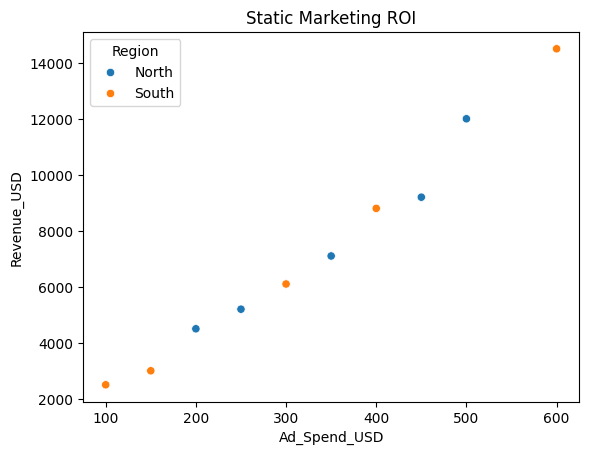

In [6]:
data = {
    "Day": [1,2,3,4,5,6,7,8,9,10],
    "Ad_Spend_USD":[200,500,150,300,450,100,250,600,350,400],
    "Revenue_USD":[4500,12000,3000,6100,9200,2500,5200,14500,7100,8800],
    "Product_Name":["Laptop","Laptop","Mouse","Keyboard","Laptop","Mouse","Keyboard","Laptop","Keyboard","Mouse"],
    "Region":["North","North","South","South","North","South","North","South","North","South"]
}

df_sales = pd.DataFrame(data)
df_sales.head()

sns.scatterplot(
    data=df_sales,
    x="Ad_Spend_USD",
    y="Revenue_USD",
    hue="Region"
)

plt.title("Static Marketing ROI")
plt.show()

fig = px.scatter(
    df_sales,
    x="Ad_Spend_USD",
    y="Revenue_USD",
    color="Region",
    hover_data=["Product_Name"],
    title="Interactive Marketing ROI"
)

fig.show()

In [9]:
from dash import Dash, html, dcc, Input, Output
import plotly.express as px
import pandas as pd

app = Dash(__name__)

app.layout = html.Div(style={"fontFamily": "sans-serif", "padding": "20px"}, children=[
    html.H1("The Grand Bazaar: Real-Time Performance Portal", style={"textAlign": "center", "color": "#1F4E79"}),
    html.P("Select geographical slice parameters below to re-evaluate system models:", style={"textAlign": "center"}),
    
    html.Div(style={"width": "30%", "margin": "0 auto", "paddingBottom": "20px"}, children=[
        html.Label("Target Region Filter:", style={"fontWeight": "bold"}),
        dcc.Dropdown(
            id="region-dropdown-selector",
            options=[{"label": "All Regions", "value": "ALL"},
                     {"label": "North Core", "value": "North"},
                     {"label": "South Core", "value": "South"}],
            value="ALL",    
            clearable=False    # Prevents stakeholders from leaving the system in an empty state
        )
    ]),
    
    html.Div(style={"display": "flex", "gap": "20px"}, children=[
        html.Div(dcc.Graph(id="revenue-trend-line-plot"), style={"width": "50%"}),
        html.Div(dcc.Graph(id="product-performance-bar-plot"), style={"width": "50%"})
    ])
])


@app.callback(
    [Output("revenue-trend-line-plot", "figure"),
     Output("product-performance-bar-plot", "figure")],
    [Input("region-dropdown-selector", "value")]
)
def update_dashboard_visuals(selected_region):
   
    filtered_df = df_sales.copy()
    
    if selected_region != "ALL":
        filtered_df = filtered_df[filtered_df["Region"] == selected_region]

    line_fig = px.line(
        filtered_df.sort_values(by="Day"), 
        x="Day", 
        y="Revenue_USD", 
        title=f"Operational Revenue Trend Line ({selected_region})",
        markers=True,
        template="plotly_white"
    )
    

    prod_summary = filtered_df.groupby("Product_Name")["Revenue_USD"].sum().reset_index()
    bar_fig = px.bar(
        prod_summary, 
        x="Product_Name", 
        y="Revenue_USD", 
        title=f"Product Revenue Contribution ({selected_region})",
        color="Product_Name",
        template="plotly_white"
    )
    
    return line_fig, bar_fig

if __name__ == "__main__":
    # run_server launches a local background process engine at http://127.0.0.1:8050
    app.run(debug=True, use_reloader=False)